# **PicassoPy Workshop --> Test case: cpv 2024-08-21**
---


- Folder for data `test_case_data` -> download separately
- Folder for configs `test_case_config`

The autoreload below is needed to directly pull in changes in the picassopy source code

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Imports

In [21]:
import os, sys
import argparse
import datetime
import logging
from pathlib import Path
import numpy as np
import scipy

sys.path.append('../')
import ppcpy
import ppcpy.io.loadConfigs as loadConfigs
import ppcpy.io.readPollyRawData as readPollyRawData
import ppcpy.interface.picassoProc as picassoProc
import ppcpy.misc.helper as helper
import ppcpy.misc.startscreen as startscreen
from ppcpy.io.write2nc import write_channelwise_2_nc_file, write2nc_file, write_profile2nc_file

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab20.colors)

### Helper functions

In [22]:
def get_regions(flag:np.ndarray) -> list:
    """Get regions (start, end) from 1 dim flag."""
    valid_regions = []
    layer, Nlayers = scipy.ndimage.label(flag)
    for i in range(1, Nlayers+1):
        start = np.where(layer == i)[0][0]
        stop = np.where(layer == i)[0][-1]
        valid_regions.append([start, stop])
    return valid_regions


## Defining Script Inputs

- The parameters `args.device`, `args.timestamp`, `args.picasso_config_file`, `args.level0_file_to_process`, need to be manually specified per case.
- The parameter `DATABASE_PATH` is the path to the database used for storing the retrieved calibration constants

In [23]:
## For purpose of the notebook mimic the argparse interface
from types import SimpleNamespace
args = SimpleNamespace()

## The used device and time of measurement
args.device = 'pollyxt_cpv'
args.timestamp = '20240821'
dt = datetime.datetime.strptime(args.timestamp, "%Y%m%d")

## The used config file
args.picasso_config_file = "test_case_config/pollynet_processing_chain_config_test.json"

## The data file to use
args.level0_file_to_process = f"test_case_data/{dt:%Y_%m_%d_%a}_CPV_00_00_01.nc"


## Database path
DATABASE_PATH = "PicassoPyDatabase.db"

In [24]:
startscreen.startscreen()

      ____  _                            ____           ___ ____ 
     / __ \(_)________ _______________  / __ \__  __   <  // __ \
    / /_/ / / ___/ __ `/ ___/ ___/ __ \/ /_/ / / / /   / // / / /
   / ____/ / /__/ /_/ (__  |__  ) /_/ / ____/ /_/ /   / // /_/ / 
  /_/   /_/\___/\__,_/____/____/\____/_/    \__, /   /_(_)____/  
                                           /____/                


## Load Data and Config-files

Loads data and information from the config files into the following three dictionaries:
- `picasso_config_dict`: Paths and other information stored in the picasso config file
- `polly_config_dict`: Configuration variables from polly config and polly default files
- `rawdata_dict`: Measurement data and information extracted from the level0 file

In [25]:
## Path to default Picasso config file
picasso_default_config_file = Path(
    helper.detect_path_type(Path.cwd().parent), 'ppcpy', 'config', 'pollynet_processing_chain_config.json')

## Load Picasso config file
picasso_config_dict = loadConfigs.loadPicassoConfig(args.picasso_config_file, picasso_default_config_file)

## load polly config file
polly_config_array = loadConfigs.readPollyNetConfigLinkTable(picasso_config_dict['pollynet_config_link_file'], timestamp=args.timestamp, device=args.device)
polly_config_dict = loadConfigs.getPollyConfigfromArray(
    polly_config_array, picasso_config_dict
)

## Load level0-data file
rawfile_fullname = args.level0_file_to_process
rawfile = helper.detect_path_type(rawfile_fullname)
rawdata_dict = readPollyRawData.readPollyRawData(rawfile)

2026-08-03 11:34:49,442 - INFO - picasso_default_config_file: c:\Users\buholdt\Documents\PicassoPy\ppcpy\config\pollynet_processing_chain_config.json
2026-08-03 11:34:49,445 - INFO - picasso_config_file: test_case_config/pollynet_processing_chain_config_test.json
2026-08-03 11:34:49,447 - INFO - pollynet_config_link_file: test_case_config/pollynet_processing_chain_config_links.xlsx


2026-08-03 11:34:49,506 - INFO - polly_default_config_file: c:\Users\buholdt\Documents\PicassoPy\ppcpy\config\polly_global_config.json
2026-08-03 11:34:49,509 - INFO - polly_config_file: test_case_config\pollyxt_cpv_config_20230927.json
2026-08-03 11:34:49,511 - INFO - keys default/template file, but not in specific file {'zLim_VolDepol_1064', 'ice_thres_vol_depol', 'zLim_VolDepol_532', 'turbid_thres_par_beta_1064', 'refH_FR_1064', 'depol_cal_time_fixed_m_start', 'tempCorFunc', 'depol_cal_time_fixed_p_end', 'polCaliEta532', 'droplet_thres_par_depol', 'isParallel', 'yLim_all_profiles_high_range', 'volDepolerror532', 'zLim_FR_RCS_387', 'zLim_NR_RCS_387', 'zLim_NR_RCS_407', 'logbookFileName', 'zLim_FR_RCS_607', 'logbookPath', 'polCaliEtaStd532', 'deltaT', 'polCaliEtaStd1064', 'ice_thres_par_depol', 'clear_thres_par_beta_1064', 'volDepolerror1064', 'refH_FR_532', 'flagSigTempCor', 'polCaliEta1064', 'flagMolDepolCali', 'zLim_NR_RCS_607', 'yLim_all_profiles_low_range', 'unspheroid_thres_par_

## Initialize PicassoProc object

PicassoProc is the main object in the PicassoPy, and is responsible for running all processes included and storing the data.

In [26]:
## Quick fix for shortening the measurement
time_period = [0, 500]
rawdata_dict['raw_signal']['var_data'] = rawdata_dict['raw_signal']['var_data'][slice(*time_period),...]
rawdata_dict['measurement_shots']['var_data'] = rawdata_dict['measurement_shots']['var_data'][slice(*time_period),...]
rawdata_dict['measurement_time']['var_data'] = rawdata_dict['measurement_time']['var_data'][slice(*time_period),...]
rawdata_dict['depol_cal_angle']['var_data'] = rawdata_dict['depol_cal_angle']['var_data'][slice(*time_period),...]
rawdata_dict['location_coordinates']['var_data'] = rawdata_dict['location_coordinates']['var_data'][slice(*time_period),...]

In [27]:
## Initialize PicassoProc
data_cube = picassoProc.PicassoProc(rawdata_dict, polly_config_dict, picasso_config_dict)

In [28]:
## reset date if date in filename differs date within nc-file 
data_cube.reset_date_infile()

## checking for correct mshots
data_cube.check_for_correct_mshots()

## setting channelTags
data_cube.setChannelTags()

## check for correct date in nc-file
data_cube.reset_date_infile()

2026-08-03 11:34:54,491 - INFO - date consistency-check... 
2026-08-03 11:34:54,495 - INFO - ... date in nc-file equals date of filename
2026-08-03 11:34:54,499 - INFO - ChannelLabels: ['FR-total-355 nm', 'FR-cross-355 nm', 'FR-387 nm', 'FR-407 nm', 'FR-total-532 nm', 'FR-cross-532 nm', 'FR-607 nm', 'FR-total-1064 nm', 'NR-total-532 nm', 'NR-607 nm', 'NR-total-355 nm', 'NR-387 nm', 'DFOV', '1058', '1064s', 'none']
2026-08-03 11:34:54,502 - WARNING - removed none tag from channel list [15]
2026-08-03 11:34:54,506 - INFO - date consistency-check... 
2026-08-03 11:34:54,509 - INFO - ... date in nc-file equals date of filename


## Preprocessing & Saturation Detection

The preprocessing includes the following processes:
- Deadtime correction
- Background correction
- SNR claculations
- Flagging of data
- Range correction

In [29]:
## Perform preprocessing, this includes Dead-time correction, Background correction, and Range correction
data_cube.preprocessing(collect_debug=True)

2026-08-03 11:34:54,638 - INFO - starting data preprocessing...
2026-08-03 11:34:54,641 - INFO - ... time conversion
2026-08-03 11:34:54,658 - WARNING - ... mShots not constant min 2993 max 2999
2026-08-03 11:34:54,662 - INFO - ... Deadtime-correction (Mode: 1)


mShots_norm (500, 15) mShots_norm [2995.756 2995.756 2995.756 2995.756 2995.756 2995.756 2995.756 2995.756
 2995.738 2995.738 2995.738 2995.738 2995.738 2995.738 2995.738]


2026-08-03 11:34:59,061 - INFO - ... removing background from signal
2026-08-03 11:34:59,702 - INFO - ... height bin calculations
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\preprocess\pollyPreprocess.py:653: UserWarning: no explicit representation of timezones available for np.datetime64
  data_dict['time64'] = np.array([np.datetime64(t) for t in mTime_obj])
2026-08-03 11:34:59,837 - INFO - ... mask bins with low SNR
2026-08-03 11:35:01,681 - INFO - ... mask for polarization calibration
2026-08-03 11:35:01,686 - INFO - ... calculate range-corrected Signal


flag 532 FR [False False False False  True False False False False False False False
 False False False]
flag 355 FR [ True False False False False False False False False False False False
 False False False]
flag 607 FR [False False False False False False  True False False False False False
 False False False]
flagNDepCal [False False False False False False False False False False False False
  True  True  True  True  True  True  True  True False]
flagPDepCal [False False  True  True  True  True  True  True  True  True False False
 False False False False False False False False False]
depCalPeriods [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0

2026-08-03 11:35:02,137 - INFO - finished data preprocessing.


(500, 4000, 15)
ranges2d (500, 4000)


In [30]:
## Display available channels
data_cube.channel_dict

{0: 'FR-total-355 nm',
 1: 'FR-cross-355 nm',
 2: 'FR-387 nm',
 3: 'FR-407 nm',
 4: 'FR-total-532 nm',
 5: 'FR-cross-532 nm',
 6: 'FR-607 nm',
 7: 'FR-total-1064 nm',
 8: 'NR-total-532 nm',
 9: 'NR-607 nm',
 10: 'NR-total-355 nm',
 11: 'NR-387 nm',
 12: 'DFOV',
 13: '1058',
 14: '1064s'}

## Cloud Screening

Three modes of cloud Screening are currently implemented:

0. No cloud screening. Return cloud free for all timestamps
1. Cloud screen with Maximum Gradient Signal (MSG) algorithm
2. Cloud screen with Zhao's algorithm

Clouds are screened per timestamp (30s). After the screening the data is split up into cloud free segments and aggregated.

In [31]:
## Apply cloud screening
data_cube.cloudScreen() # --> produces the variable data_cube.flagCloudFree

## Display cloud free mask
data_cube.flagCloudFree # --> A one dimensional flag. False for cloudy timestamps and True for cloud free timestamps.

2026-08-03 11:35:02,928 - INFO - cloud screen mode 1: MSG method.


Starting cloud screen


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [32]:
## Segmentate cloud free groups
data_cube.cloudFreeSeg() # --> produces the variable data_cube.clFreeGrps
                         # --> and data_cube.flagValPrf

## Display cloud free groups
display(data_cube.clFreeGrps) # --> Subsequent regions of cloud free timestamps (start, stop)
display(data_cube.flagValPrf) # --> A one dimensional flag for valid profiles. Combination of data_cube.flagCloudFree and other flags like fogMask, shutterOnMask etc.

intNProfiles 120 minIntNProfiles 30


array([[  0, 113],
       [144, 244]])

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

## Example: Exclude individual cloudy profiles

In [33]:
# Overwrite cloud free groups for the sake of the example
data_cube.clFreeGrps = np.array([[325, 365]])

# Display the new cloud free groups
data_cube.clFreeGrps

array([[325, 365]])

### Plot cloud free groups and invalid profiles

'There are invalid timestamps inside the manually selected cloud free group'

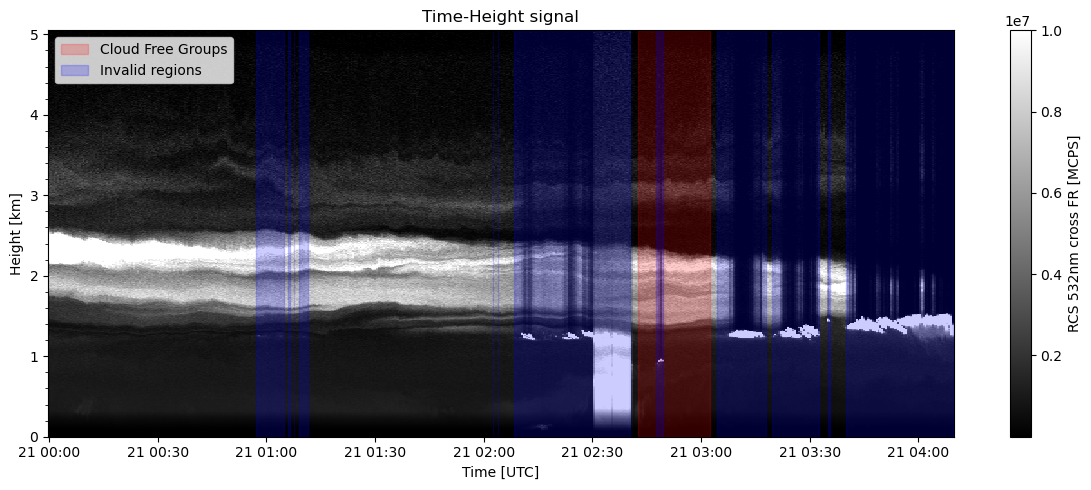

In [34]:
wv, t, tel = 532, 'cross', 'FR'

fig, ax = plt.subplots(figsize=(12, 5))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    np.squeeze(data_cube.retrievals_highres['RCS'][:, :, data_cube.gf(wv, t, tel)]).T,
    shading='nearest',
    vmin=5, vmax=1e7,
    cmap='gray'
)

for i, cldFreGrp in enumerate(data_cube.clFreeGrps):
    label = None
    if i == 0:
        label = "Cloud Free Groups"
    ax.axvspan(
        data_cube.retrievals_highres["time64"][cldFreGrp[0]],
        data_cube.retrievals_highres["time64"][cldFreGrp[1]],
        color="red", alpha=0.2, label=label
    )
for i, region in enumerate(get_regions(~data_cube.flagValPrf)):
    label = None
    if i == 0:
        label = "Invalid regions"
    ax.axvspan(
        data_cube.retrievals_highres["time64"][region[0]],
        data_cube.retrievals_highres["time64"][region[1]],
        color="blue", alpha=0.2, label=label
    )

cbar = fig.colorbar(pcmesh)
cbar.set_label(f'RCS {wv}nm {t} {tel} [MCPS]')
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator())
ax.set_xlabel('Time [UTC]')
ax.set_ylabel('Height [km]')
ax.set_title('Time-Height signal')
ax.set_ylim(0, 5.05)
ax.legend(loc="upper left")
fig.tight_layout()

"""There are invalid timestamps inside the manually selected cloud free group"""

### Aggregate background, background corrected signal, and range corrected signal

- A new input parameter `flagVal` has been added to the function `data_cube.aggregate_profiles()`.

- When`flagVal=True`, only profiles where `data_cube.flagValPrf=True` will be considered in the aggregation process.

- When `flagVal=False`, all profiles inside the cloud free group will be considred in the aggregation process.

- If `type(flagVal)=np.ndarray`, only profiles where `flagVal=True` will be considered in the aggregation process.

- By manipulating `data_cube.flagValPrf` before running `data_cube.aggregate_profiles(flagVal=True)`, 
or manipulating the input `flagVal` directly, it is possible to exclude specific profiles from the aggregation process.

#### Scenario 1: Aggregating all profiles in the cloud free group

(41, 4000, 15)
(41, 4000, 15)
(41, 4000, 15)
(41, 4000, 15)
(41, 15)
(41, 15)


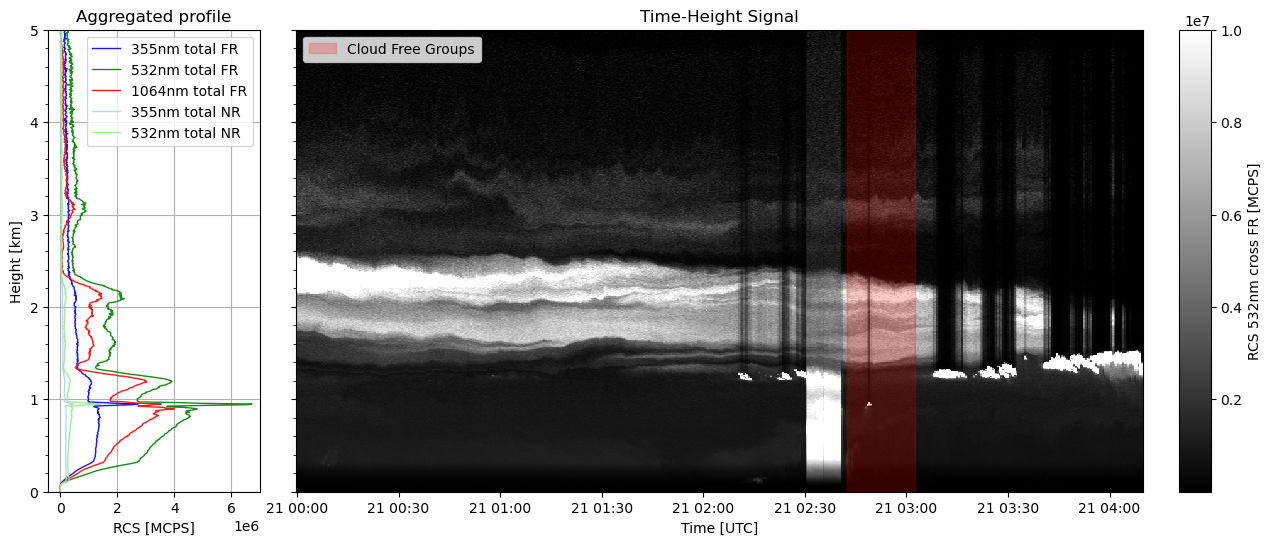

In [35]:
## Setting flagValPrf to be True for all elements
data_cube.flagValPrf = np.ones_like(data_cube.retrievals_highres['time'], dtype=bool)

## Aggregate all profiles in the cloud free groups
data_cube.aggregate_profiles(flagVal=True)

## This is the same as running the function with flagVal=False
# data_cube.aggregate_profiles(flagVal=False)



## -------------- Visualization --------------
T, H = np.meshgrid(data_cube.retrievals_highres['time64'], data_cube.retrievals_highres['height'])

## Layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(
    1, 3,
    width_ratios=[1, 4, 0.15],
    wspace=0.1
)
ax_prof = fig.add_subplot(gs[0])
ax_main = fig.add_subplot(gs[1], sharey=ax_prof)
cax = fig.add_subplot(gs[2])

## Profile plot
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(1064, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm total NR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm total NR')
ax_prof.grid()
ax_prof.set_ylim(0, 5)
ax_prof.set_xlim(right=7e6)
ax_prof.legend(loc='upper right')
ax_prof.set_ylabel('Height [km]')
ax_prof.set_xlabel('RCS [MCPS]')
ax_prof.set_title('Aggregated profile')

## time-height plot
wv, t, tel = 532, 'cross', 'FR'
pcmesh = ax_main.pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    np.squeeze(data_cube.retrievals_highres['RCS'][:, :, data_cube.gf(wv, t, tel)]).T,
    shading='nearest',
    vmin=5, vmax=1e7,
    cmap='gray'
)
for i, cldFreGrp in enumerate(data_cube.clFreeGrps):
    label = None
    if i == 0:
        label = "Cloud Free Groups"
    ax_main.axvspan(
        data_cube.retrievals_highres["time64"][cldFreGrp[0]],
        data_cube.retrievals_highres["time64"][cldFreGrp[1]],
        color="red", alpha=0.2, label=label
    )
for i, region in enumerate(get_regions(~data_cube.flagValPrf)):
    label = None
    if i == 0:
        label = "Invalid regions"
    ax_main.axvspan(
        data_cube.retrievals_highres["time64"][region[0]],
        data_cube.retrievals_highres["time64"][region[1]],
        color="blue", alpha=0.2, label=label
    )
cbar = fig.colorbar(pcmesh, cax=cax)
cbar.set_label(f'RCS {wv}nm {t} {tel} [MCPS]')
ax_main.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator())
ax_main.set_xlabel('Time [UTC]')
ax_main.set_title('Time-Height Signal')
ax_main.set_ylim(0, 5)
ax_main.legend(loc="upper left")

# Hide duplicate y labels
plt.setp(ax_main.get_yticklabels(), visible=False)
plt.show()

#### Scenario 2: Use the default (automatically retrieved) `data_cube.flagValPrf`

(41, 4000, 15)
(36, 4000, 15)
(41, 4000, 15)
(36, 4000, 15)
(41, 15)
(36, 15)


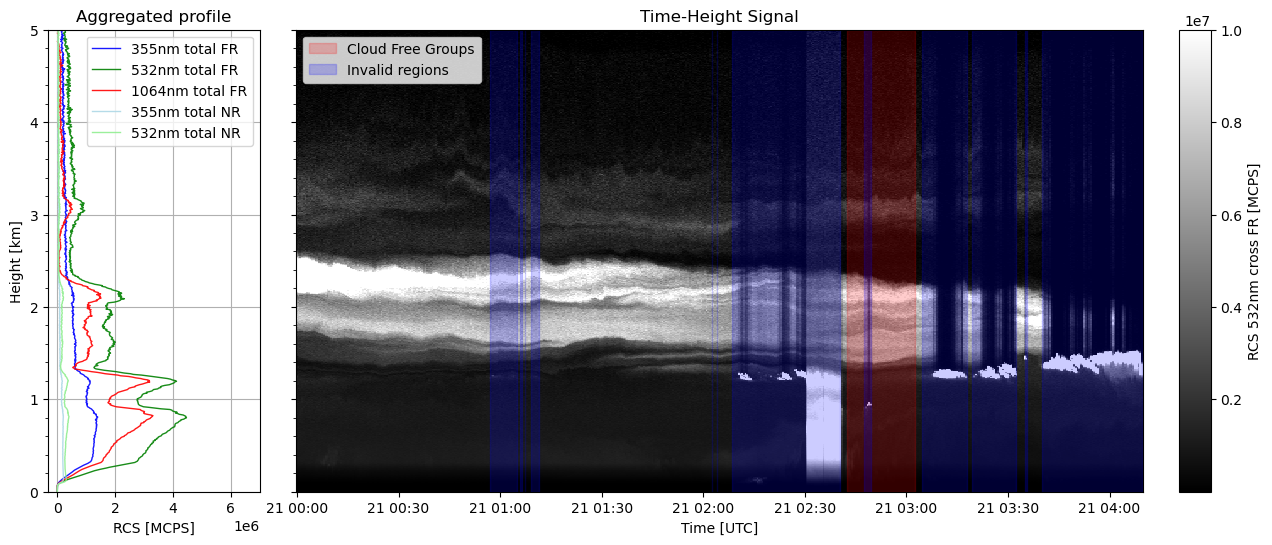

In [36]:
## Reset data_cube.flagValPrf
data_cube.genFlagValPrf()

## Aggregate only valid profiles in the cloud free groups, as found by the automatic retrieval.
data_cube.aggregate_profiles(flagVal=True)




## -------------- Visualization --------------
T, H = np.meshgrid(data_cube.retrievals_highres['time64'], data_cube.retrievals_highres['height'])

## Layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(
    1, 3,
    width_ratios=[1, 4, 0.15],
    wspace=0.1
)

ax_prof = fig.add_subplot(gs[0])
ax_main = fig.add_subplot(gs[1], sharey=ax_prof)
cax = fig.add_subplot(gs[2])

## Profile plot
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(1064, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm total NR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm total NR')
ax_prof.grid()
ax_prof.set_ylim(0, 5)
ax_prof.set_xlim(right=7e6)
ax_prof.legend(loc='upper right')
ax_prof.set_ylabel('Height [km]')
ax_prof.set_xlabel('RCS [MCPS]')
ax_prof.set_title('Aggregated profile')

## time-height plot
wv, t, tel = 532, 'cross', 'FR'
pcmesh = ax_main.pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    np.squeeze(data_cube.retrievals_highres['RCS'][:, :, data_cube.gf(wv, t, tel)]).T,
    shading='nearest',
    vmin=5, vmax=1e7,
    cmap='gray'
)
for i, cldFreGrp in enumerate(data_cube.clFreeGrps):
    label = None
    if i == 0:
        label = "Cloud Free Groups"
    ax_main.axvspan(
        data_cube.retrievals_highres["time64"][cldFreGrp[0]],
        data_cube.retrievals_highres["time64"][cldFreGrp[1]],
        color="red", alpha=0.2, label=label
    )
for i, region in enumerate(get_regions(~data_cube.flagValPrf)):
    label = None
    if i == 0:
        label = "Invalid regions"
    ax_main.axvspan(
        data_cube.retrievals_highres["time64"][region[0]],
        data_cube.retrievals_highres["time64"][region[1]],
        color="blue", alpha=0.2, label=label
    )
cbar = fig.colorbar(pcmesh, cax=cax)
cbar.set_label(f'RCS {wv}nm {t} {tel} [MCPS]')
ax_main.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator())
ax_main.set_xlabel('Time [UTC]')
ax_main.set_title('Time-Height Signal')
ax_main.set_ylim(0, 5)
ax_main.legend(loc="upper left")

# Hide duplicate y labels
plt.setp(ax_main.get_yticklabels(), visible=False)
plt.show()

#### Scenario 3: Modify `data_cube.flagValPrf` to exclude specific unwanted profiles.

(41, 4000, 15)
(24, 4000, 15)
(41, 4000, 15)
(24, 4000, 15)
(41, 15)
(24, 15)


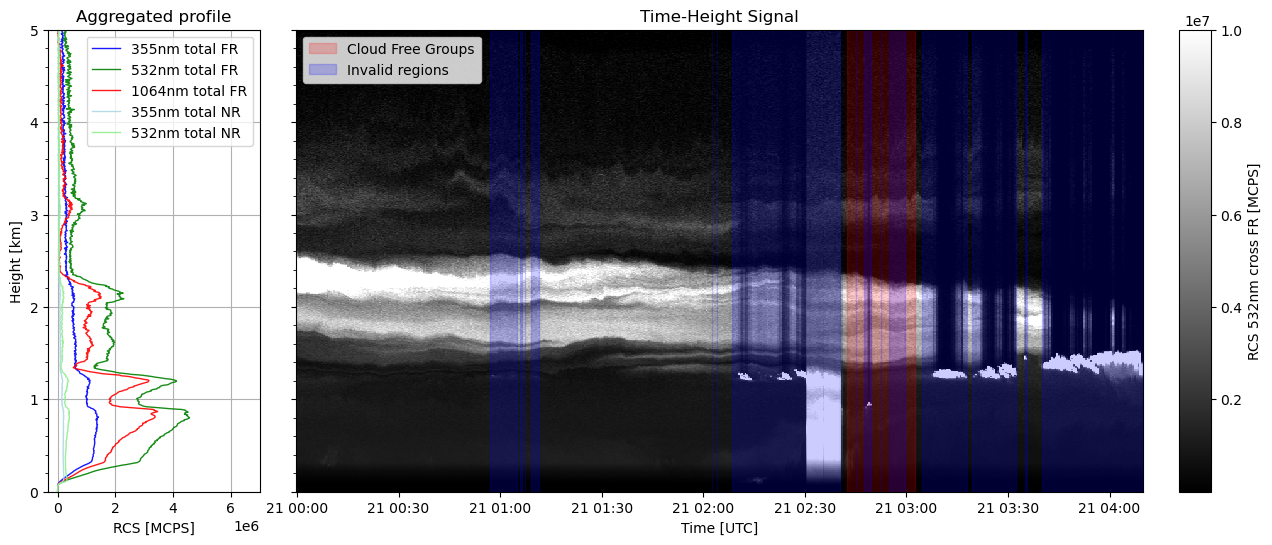

In [37]:
## Manually set a specific unwanted part of the data_cube.flagValPrf to False
data_cube.flagValPrf[330] = False
data_cube.flagValPrf[345] = False
data_cube.flagValPrf[350:360] = False


## Aggregate only manually set valid profiles in the cloud free groups.
data_cube.aggregate_profiles(flagVal=True)




## -------------- Visualization --------------
T, H = np.meshgrid(data_cube.retrievals_highres['time64'], data_cube.retrievals_highres['height'])

## Layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(
    1, 3,
    width_ratios=[1, 4, 0.15],
    wspace=0.1
)

ax_prof = fig.add_subplot(gs[0])
ax_main = fig.add_subplot(gs[1], sharey=ax_prof)
cax = fig.add_subplot(gs[2])

## Profile plot
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(1064, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm total NR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm total NR')
ax_prof.grid()
ax_prof.set_ylim(0, 5)
ax_prof.set_xlim(right=7e6)
ax_prof.legend(loc='upper right')
ax_prof.set_ylabel('Height [km]')
ax_prof.set_xlabel('RCS [MCPS]')
ax_prof.set_title('Aggregated profile')

## time-height plot
wv, t, tel = 532, 'cross', 'FR'
pcmesh = ax_main.pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    np.squeeze(data_cube.retrievals_highres['RCS'][:, :, data_cube.gf(wv, t, tel)]).T,
    shading='nearest',
    vmin=5, vmax=1e7,
    cmap='gray'
)
for i, cldFreGrp in enumerate(data_cube.clFreeGrps):
    label = None
    if i == 0:
        label = "Cloud Free Groups"
    ax_main.axvspan(
        data_cube.retrievals_highres["time64"][cldFreGrp[0]],
        data_cube.retrievals_highres["time64"][cldFreGrp[1]],
        color="red", alpha=0.2, label=label
    )
for i, region in enumerate(get_regions(~data_cube.flagValPrf)):
    label = None
    if i == 0:
        label = "Invalid regions"
    ax_main.axvspan(
        data_cube.retrievals_highres["time64"][region[0]],
        data_cube.retrievals_highres["time64"][region[1]],
        color="blue", alpha=0.2, label=label
    )
cbar = fig.colorbar(pcmesh, cax=cax)
cbar.set_label(f'RCS {wv}nm {t} {tel} [MCPS]')
ax_main.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator())
ax_main.set_xlabel('Time [UTC]')
ax_main.set_title('Time-Height Signal')
ax_main.set_ylim(0, 5)
ax_main.legend(loc="upper left")

# Hide duplicate y labels
plt.setp(ax_main.get_yticklabels(), visible=False)
plt.show()

### Scenario 4: Modify the input of `data_cube.aggregate_profiles()` directly to exclude unwanted profiles

(41, 4000, 15)
(34, 4000, 15)
(41, 4000, 15)
(34, 4000, 15)
(41, 15)
(34, 15)


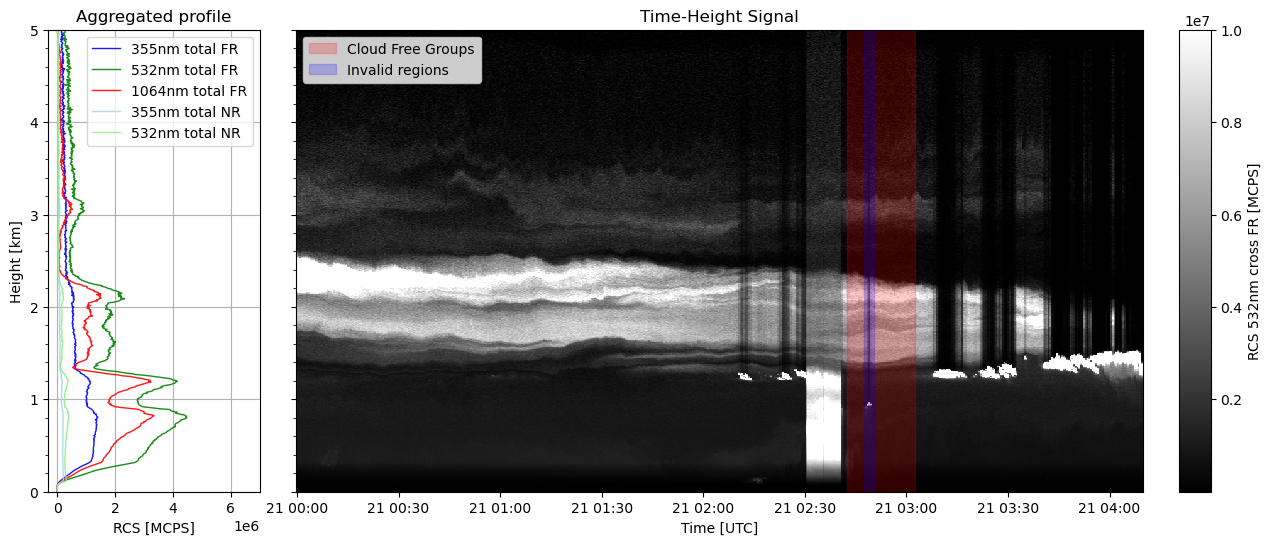

In [38]:
## It is also possible to input a boolean array of the valid profiles directly to data_cube.aggregate_profiles() function
## without manipulating data_cube.flagValPrf first.
flagVal = np.ones_like(data_cube.retrievals_highres['time64'], dtype=bool)
flagVal[335:342] = False


## Aggregate only manually set valid profiles in the cloud free groups.
data_cube.aggregate_profiles(flagVal=flagVal)




## -------------- Visualization --------------
T, H = np.meshgrid(data_cube.retrievals_highres['time64'], data_cube.retrievals_highres['height'])

## Layout
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(
    1, 3,
    width_ratios=[1, 4, 0.15],
    wspace=0.1
)

ax_prof = fig.add_subplot(gs[0])
ax_main = fig.add_subplot(gs[1], sharey=ax_prof)
cax = fig.add_subplot(gs[2])

## Profile plot
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(1064, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm total FR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm total NR')
ax_prof.plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm total NR')
ax_prof.grid()
ax_prof.set_ylim(0, 5)
ax_prof.set_xlim(right=7e6)
ax_prof.legend(loc='upper right')
ax_prof.set_ylabel('Height [km]')
ax_prof.set_xlabel('RCS [MCPS]')
ax_prof.set_title('Aggregated profile')

## time-height plot
wv, t, tel = 532, 'cross', 'FR'
pcmesh = ax_main.pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    np.squeeze(data_cube.retrievals_highres['RCS'][:, :, data_cube.gf(wv, t, tel)]).T,
    shading='nearest',
    vmin=5, vmax=1e7,
    cmap='gray'
)
for i, cldFreGrp in enumerate(data_cube.clFreeGrps):
    label = None
    if i == 0:
        label = "Cloud Free Groups"
    ax_main.axvspan(
        data_cube.retrievals_highres["time64"][cldFreGrp[0]],
        data_cube.retrievals_highres["time64"][cldFreGrp[1]],
        color="red", alpha=0.2, label=label
    )
for i, region in enumerate(get_regions(~flagVal)):
    label = None
    if i == 0:
        label = "Invalid regions"
    ax_main.axvspan(
        data_cube.retrievals_highres["time64"][region[0]],
        data_cube.retrievals_highres["time64"][region[1]],
        color="blue", alpha=0.2, label=label
    )
cbar = fig.colorbar(pcmesh, cax=cax)
cbar.set_label(f'RCS {wv}nm {t} {tel} [MCPS]')
ax_main.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator())
ax_main.set_xlabel('Time [UTC]')
ax_main.set_title('Time-Height Signal')
ax_main.set_ylim(0, 5)
ax_main.legend(loc="upper left")

# Hide duplicate y labels
plt.setp(ax_main.get_yticklabels(), visible=False)
plt.show()